# Direct preference optimization and reference-corrected margins

CPU companion; no accelerator is required. TPU execution not validated.

- Compare chosen and rejected response log probabilities
- Subtract the reference preference
- Verify the changed-condition exercise and explain the limits of this fixture.

Can we train on chosen/rejected responses without collecting fresh reward-model rollouts? DPO provides a different training objective. We will work through the reference correction and compare its bookkeeping with the preceding RLHF loop.

## The idea

DPO uses chosen/rejected preferences and a fixed reference to optimize a policy directly. It compares policy log-probability differences with reference differences. This training step does not require an explicit reward-model call or on-policy rollout.

## A better relative margin need not raise chosen probability

Suppose chosen probability falls from $0.4$ to $0.3$ while rejected probability falls from $0.2$ to $0.1$. The chosen-to-rejected ratio rises from $2$ to $3$, even though the chosen probability decreased. Relative preference improvement and absolute likelihood improvement are different claims.

The reference corrects that log-ratio margin, and beta scales it in the loss. Keep the reference checkpoint and any cached reference probabilities bound to the same examples and preprocessing.

Read the margin plot alongside individual probabilities when diagnosing behavior. A growing training margin does not establish held-out preference quality or generation quality. The categorical fixture teaches the objective; sequence integration also needs token masking and log-probability aggregation checks.

### DPO corrects a policy margin with a reference

**Predict:** What extra evidence would you inspect before claiming a DPO update makes chosen responses more likely?

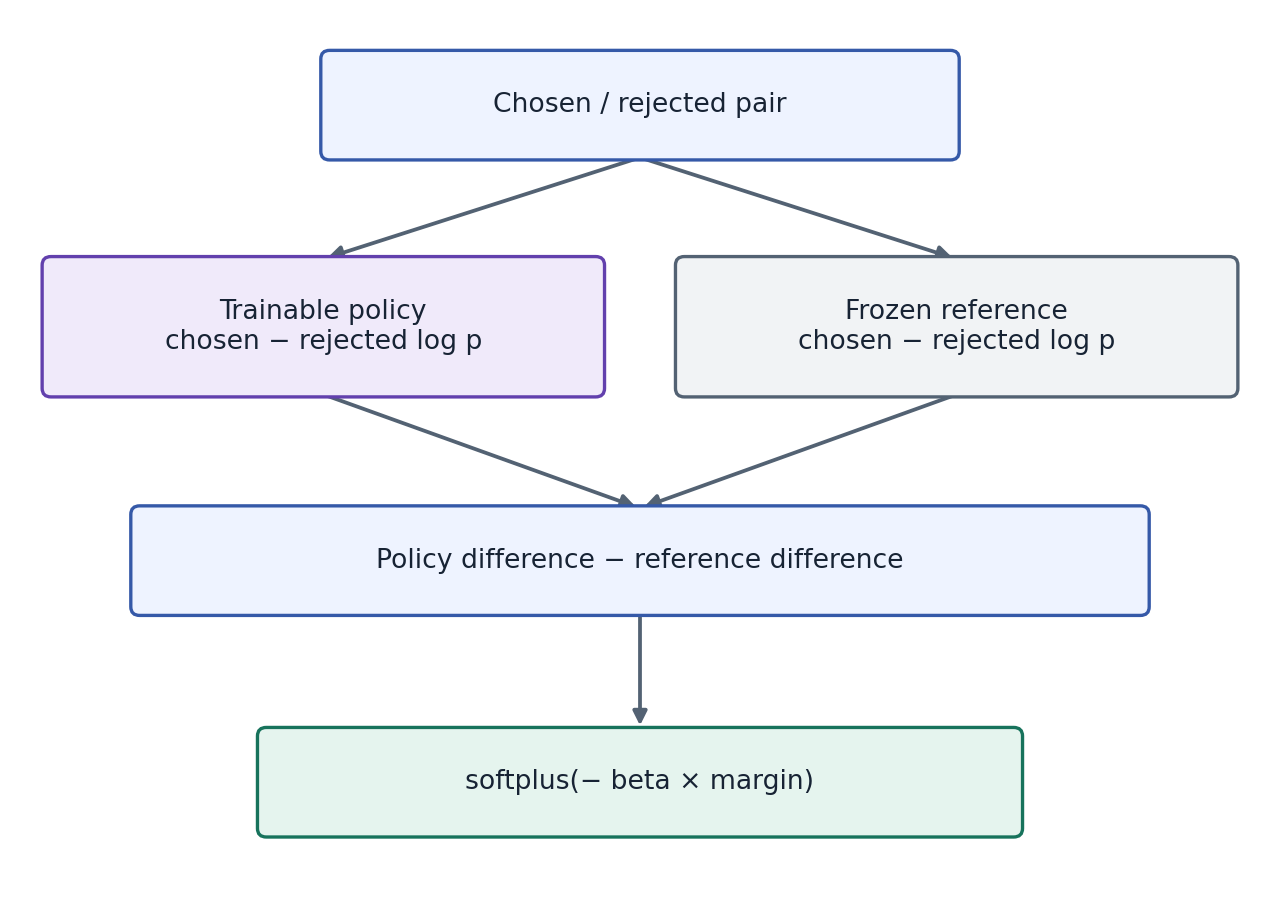

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Both models score the same chosen/rejected pair. Their log-probability differences form a reference-corrected margin, which beta scales before the stable preference loss. The reference is frozen. There is no reward-model call or on-policy rollout in this step.

### Pause and reason

What extra evidence would you inspect before claiming a DPO update makes chosen responses more likely?

<details><summary>Compare your reasoning</summary>

Inspect chosen probabilities or sequence log probabilities directly under a fixed measurement contract. A relative margin alone cannot establish that absolute change.

</details>

## Before coding: compare changes in preference, not raw scores

Consider a prompt with one chosen and one rejected response. The reference already prefers one of them to some degree. DPO asks how the current policy changes that relative preference. Write four log probabilities: current chosen, current rejected, reference chosen and reference rejected. Take a within-model difference first, then subtract the reference difference.

When current and reference models are identical, both differences cancel even if neither response has high probability. The loss starts at $\log2$. This cancellation is a precise implementation check, not evidence that the initial model is indifferent between the two responses.

## Compare chosen and rejected response log probabilities

Both responses belong to the same prompt. Compute their sequence log probabilities under current and reference policies. Exclude prompt and padding tokens consistently. Keep lengths, tokenization and special-token rules visible because they determine the probability of the represented response.

## Subtract the reference preference

The reference-corrected margin subtracts what the reference already preferred. At initialization when current policy equals reference, the corrected margin is zero and the loss is $\log2$, even if the reference assigns unequal response probabilities.

$$
L_{\mathrm{DPO}}=\mathbb E\left[\operatorname{softplus}\!\left(-\beta\left[\log\frac{\pi_\theta(y^+|x)}{\pi_\theta(y^-|x)}-\log\frac{\pi_{\mathrm{ref}}(y^+|x)}{\pi_{\mathrm{ref}}(y^-|x)}\right]\right)\right]
$$

## Work through a numeric margin and its gradient

Suppose current chosen/rejected log probabilities are $-2$ and $-4$, while reference values are $-3$ and $-4$. The current gap is $2$, the reference gap is $1$, and the corrected margin is $1$. With $\beta=0.3$, the loss is $\log(1+e^{-0.3})$, about $0.554$. Reversing chosen and rejected flips the corrected margin.

Let $m$ denote the corrected margin. Its derivative below is negative for finite $m$, so gradient descent increases the chosen-versus-rejected gap on this pair. The underlying model shares parameters across many responses, so this local pressure does not guarantee every chosen response’s absolute probability rises.

$$
\frac{\partial L}{\partial m}=-\beta\,\sigma(-\beta m)
$$

## A rising preference ratio can hide falling chosen probability

Imagine reference probabilities $[0.4,0.4,0.2]$ for chosen, rejected and another response. A new policy $[0.3,0.1,0.6]$ lowers the chosen probability but lowers the rejected probability even more. The chosen/rejected ratio grows from one to three, so the DPO loss improves for this comparison.

Track chosen and rejected sequence log probabilities separately, not only the margin. Also evaluate useful task behavior, response length and diversity on held-out prompts. Pairwise training is a relative objective; it does not directly specify the probability allocated to every unpaired response.

## Keep the algorithm distinction visible

This loop updates from fixed preference pairs; it has no separately trained reward model or on-policy rollout stage. That does not make it PPO with a different optimizer. Both methods need a base/reference identity and reliable preference data, but their estimators, data freshness and failure modes differ.

## Treat beta and length as part of the objective

Beta scales the corrected margin and changes update behavior; it is not interchangeable with every explicit KL coefficient in a PPO implementation. Response sums and response means also differ. Make comparisons under a declared objective and evaluation protocol instead of selecting hyperparameters from a training-loss curve alone.

## Evaluate beyond chosen-pair fit

Frozen-pair optimization can overfit or reduce useful response diversity. Retain held-out prompts, independent task metrics and reviewed outputs; inspect slices rather than only average preference accuracy. Synthetic action preferences establish an objective implementation test, not an aligned language model.

## Carry sequence bookkeeping and reference identity into a real model

For language responses, add log probabilities over valid answer and end tokens while conditioning on the prompt. Exclude padding and prompt targets consistently. A mean over response length changes the objective: two equally likely tokens have twice the negative log probability of one. Decide which objective you intend rather than introducing normalization as an innocent convenience.

Reference caches must bind prompt text, chosen/rejected ordering, tokenizer, chat template, mask and checkpoint revision. A frozen array can still be wrong if its examples were reordered. Split prompt groups before fitting, compare fixed decoding on held-out tasks, and retain the actual reference artifact so a later run can reproduce the correction. This categorical lab supplies objective checks, not the sequence trainer.

## 1. Define the reference-corrected pair objective

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
# Step 1 — 1. Define the reference-corrected pair objective: The reference correction is detached, while current policy log...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Define `dpo_loss(policy_logps, reference_logps, chosen, rejected...)` to evaluate the objective and its automatic derivatives:
def dpo_loss(policy_logps, reference_logps, chosen, rejected, beta=0.2):
    # Evaluate `margin` from the current inputs and state.
    margin = (policy_logps[chosen] - policy_logps[rejected]) - jax.lax.stop_gradient(
        reference_logps[chosen] - reference_logps[rejected]
    )
    # Return `jnp.mean(jax.nn.softplus(-beta * margin))` to the caller.
    return jnp.mean(jax.nn.softplus(-beta * margin))

The reference correction is detached, while current policy log probabilities remain differentiable.

## 2. Freeze reference probabilities and comparison IDs

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
# Step 2 — 2. Freeze reference probabilities and comparison IDs: The initial policy equals a nonuniform reference.
# Initialize array `reference` with explicit values and shape.
reference = jax.nn.log_softmax(jnp.array([0.2, 0.0, -0.2]))
# Initialize array `chosen` with explicit values and shape.
chosen = jnp.array([0, 0, 1])
# Initialize array `rejected` with explicit values and shape.
rejected = jnp.array([1, 2, 2])
# Initialize array `theta` with explicit values and shape.
theta = jnp.array([0.2, 0.0, -0.2])
# Evaluate `history` from the current inputs and state.
history = []
# Evaluate numerically stable log-space cross-entropy/likelihood (`loss`).
loss = lambda theta: dpo_loss(
    jax.nn.log_softmax(theta), reference, chosen, rejected, 0.3
)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(loss(theta), np.log(2), atol=1e-6)

The initial policy equals a nonuniform reference. Predict the corrected margin and initial loss before continuing.

## 3. Fit the policy and test cancellation

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
# Step 3 — 3. Fit the policy and test cancellation: The host stable-softplus calculation checks final margins.
for _ in range(120):
    # Run `step` to compute `(value, g)`.
    value, g = step(theta)
    # Append the current step result to `history`.
    history.append(float(value))
    # Evaluate `theta` from the current inputs and state.
    theta = theta - 0.4 * g

# Verify contract: `history[-1] < history[0] * 0.5`.
assert history[-1] < history[0] * 0.5
# Evaluate numerically stable log-space cross-entropy/likelihood (`policy`).
policy = jax.nn.log_softmax(theta)
# Convert `margin` to a host NumPy array for inspection or verification.
margin = np.asarray(
    (policy[chosen] - policy[rejected]) - (reference[chosen] - reference[rejected]),
    np.float64,
)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(
    loss(theta), np.mean(np.logaddexp(0, -0.3 * margin)), atol=1e-6
)
# Verify contract: `np.all(margin > 0)`.
assert np.all(margin > 0)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(loss(theta + 50), loss(theta), atol=1e-6)
# Print the observed values to compare against the expected result.
print(
    'DPO initial/final:',
    history[0],
    history[-1],
    '; reference-corrected margins:',
    margin,
)

DPO initial/final: 0.6931471824645996 0.27227783203125 ; reference-corrected margins: [3.0890286  6.17805719 3.08902884]


The host stable-softplus calculation checks final margins. Adding a common logit offset preserves the probability distribution and therefore the objective.

## Run the example

In [4]:
# Step 1 — 1. Define the reference-corrected pair objective: The reference correction is detached, while current policy log...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Define `dpo_loss(policy_logps, reference_logps, chosen, rejected...)` to evaluate the objective and its automatic derivatives:
def dpo_loss(policy_logps, reference_logps, chosen, rejected, beta=0.2):
    # Evaluate `margin` from the current inputs and state.
    margin = (policy_logps[chosen] - policy_logps[rejected]) - jax.lax.stop_gradient(
        reference_logps[chosen] - reference_logps[rejected]
    )
    # Return `jnp.mean(jax.nn.softplus(-beta * margin))` to the caller.
    return jnp.mean(jax.nn.softplus(-beta * margin))

# Step 2 — 2. Freeze reference probabilities and comparison IDs: The initial policy equals a nonuniform reference.
# Initialize array `reference` with explicit values and shape.
reference = jax.nn.log_softmax(jnp.array([0.2, 0.0, -0.2]))
# Initialize array `chosen` with explicit values and shape.
chosen = jnp.array([0, 0, 1])
# Initialize array `rejected` with explicit values and shape.
rejected = jnp.array([1, 2, 2])
# Initialize array `theta` with explicit values and shape.
theta = jnp.array([0.2, 0.0, -0.2])
# Evaluate `history` from the current inputs and state.
history = []
# Evaluate numerically stable log-space cross-entropy/likelihood (`loss`).
loss = lambda theta: dpo_loss(
    jax.nn.log_softmax(theta), reference, chosen, rejected, 0.3
)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(loss(theta), np.log(2), atol=1e-6)

# Step 3 — 3. Fit the policy and test cancellation: The host stable-softplus calculation checks final margins.
for _ in range(120):
    # Run `step` to compute `(value, g)`.
    value, g = step(theta)
    # Append the current step result to `history`.
    history.append(float(value))
    # Evaluate `theta` from the current inputs and state.
    theta = theta - 0.4 * g

# Verify contract: `history[-1] < history[0] * 0.5`.
assert history[-1] < history[0] * 0.5
# Evaluate numerically stable log-space cross-entropy/likelihood (`policy`).
policy = jax.nn.log_softmax(theta)
# Convert `margin` to a host NumPy array for inspection or verification.
margin = np.asarray(
    (policy[chosen] - policy[rejected]) - (reference[chosen] - reference[rejected]),
    np.float64,
)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(
    loss(theta), np.mean(np.logaddexp(0, -0.3 * margin)), atol=1e-6
)
# Verify contract: `np.all(margin > 0)`.
assert np.all(margin > 0)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(loss(theta + 50), loss(theta), atol=1e-6)
# Print the observed values to compare against the expected result.
print(
    'DPO initial/final:',
    history[0],
    history[-1],
    '; reference-corrected margins:',
    margin,
)

DPO initial/final: 0.6931471824645996 0.27227783203125 ; reference-corrected margins: [3.0890286  6.17805719 3.08902884]


Expected: Reference-corrected margins become positive and the initial equal-policy loss is log(2).

## Direct preference optimization and reference-corrected margins — recorded experiment

Predict: What does a positive corrected margin establish, and what does it leave unknown about absolute probabilities?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Direct preference optimization and reference-corrected margins — recorded experiment
# Evaluate `visual_data` from the current inputs and state.
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'DPO preference loss (nats)','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
# Loop over `panel` in `visual_data.get('panels', [visual_data])`:
for panel in visual_data.get('panels',[visual_data]):
    # Evaluate `panel['x']` from the current inputs and state.
    panel['x']=panel['series'][0]['x']

# Evaluate `extra_panel` from the current inputs and state.
extra_panel={'kind':'bar','x':[0,1,2],'labels':['0 preferred to 1','0 preferred to 2','1 preferred to 2'],'series':[{'label':'final corrected margin','y':margin.tolist()}],'xlabel':'preference pair','ylabel':'reference-corrected log ratio','title':'Relative preference changes behind the loss'}
# Evaluate `visual_data` from the current inputs and state.
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}

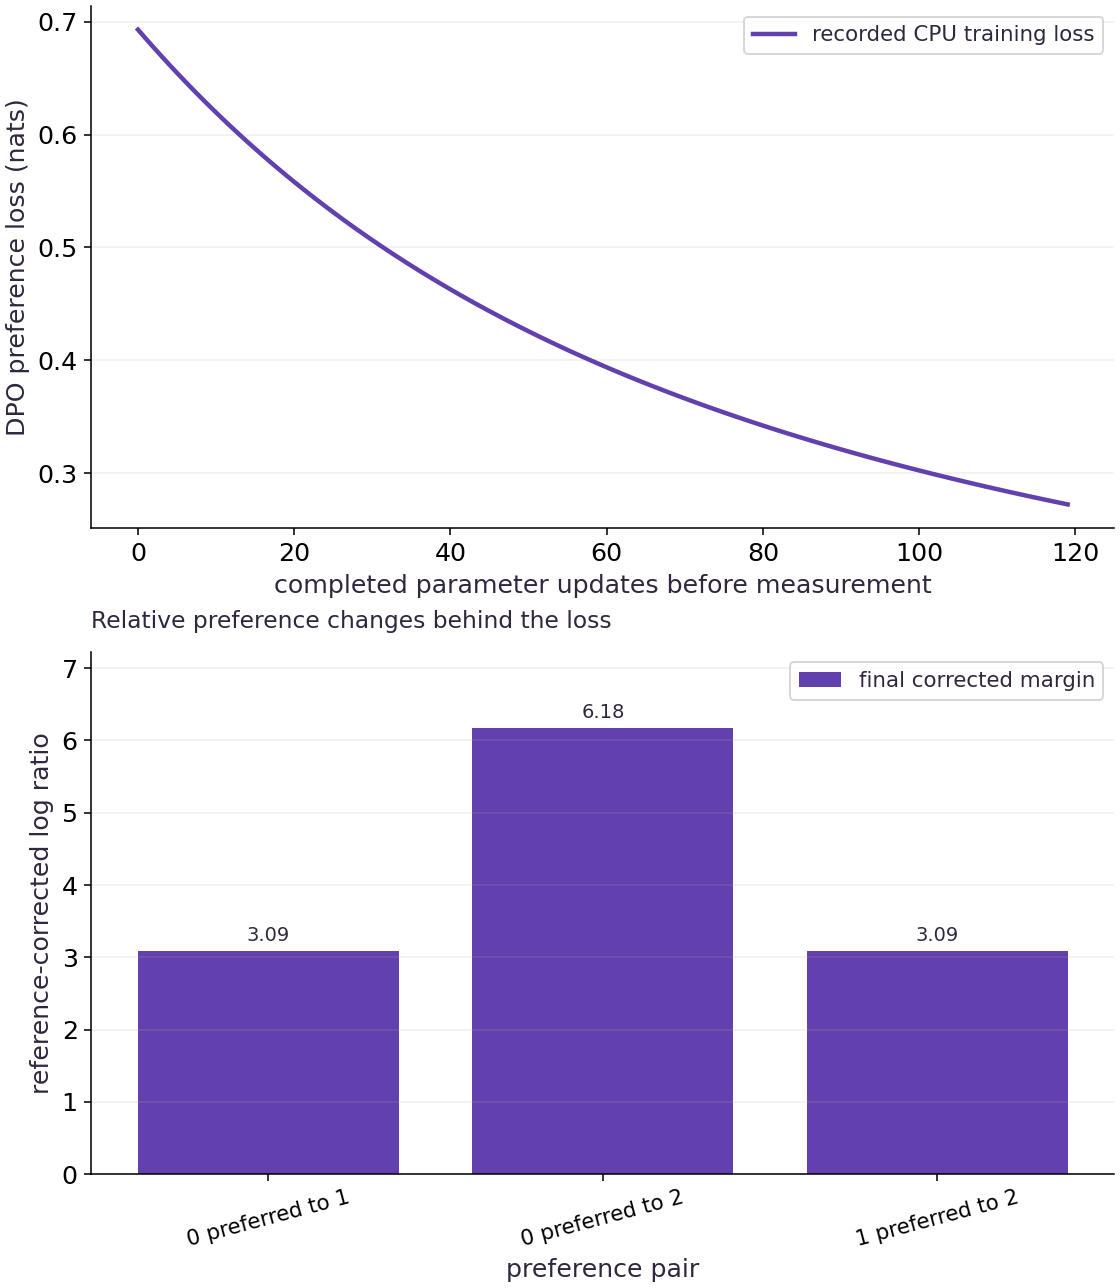

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The line records preference loss before each update, starting at $0.693$ and falling to about $0.272$. It measures fit to the same three synthetic action comparisons. Its numerical scale depends on beta and does not directly compare with reward-model NLL or PPO reward.

The second panel shows final reference-corrected margins for each comparison. All positive bars mean those pairwise ratios improved relative to the reference. The zero-versus-two margin combines the other two gaps. A positive bar does not by itself prove the absolute probability of the chosen response increased; the separate three-action counterexample demonstrates why. Read these as log-ratio differences, not probabilities or human preference scores.

### Connect it to the computation

Positive final corrected margins mean the policy favors each chosen action more strongly relative to the reference. The independent host softplus calculation and reference-gradient check establish objective behavior; separate generation and human review would be needed for a language application.

## Verify the reference cancellation

Predict: Can a nonuniform reference still start at log(2)?

In [7]:
# Experiment — Verify the reference cancellation: The initial policy is not uniform.
initial = dpo_loss(reference, reference, chosen, rejected, 0.3)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(initial, np.log(2), atol=1e-6)
# Aggregate array values to compute `uncorrected`.
uncorrected = jnp.mean(
    jax.nn.softplus(-0.3 * (reference[chosen] - reference[rejected]))
)
# Verify that the numerical values match the expected reference within tolerance.
assert not np.isclose(float(initial), float(uncorrected))
# Print the observed values to compare against the expected result.
print('Corrected/unadjusted initial loss:', float(initial), float(uncorrected))

Corrected/unadjusted initial loss: 0.6931471824645996 0.6540467739105225


Expected: The corrected initial loss is log(2); omitting the reference correction changes it.

The initial policy is not uniform. Cancellation, rather than equal response probabilities, makes the corrected margin zero.

## Improve the ratio while lowering the chosen probability

Predict: Can the preference loss fall even if the chosen response becomes less likely?

In [8]:
# Experiment — Improve the ratio while lowering the chosen probability: The rejected probability falls further.
# Initialize array `example_ref` with explicit values and shape.
example_ref = jnp.log(jnp.array([0.4, 0.4, 0.2]))
# Initialize array `example_policy` with explicit values and shape.
example_policy = jnp.log(jnp.array([0.3, 0.1, 0.6]))
# Initialize array `choice` with explicit values and shape.
choice = jnp.array([0])
# Initialize array `reject` with explicit values and shape.
reject = jnp.array([1])
# Evaluate `dpo_loss(example_ref, example_ref, choice, reject, 0.3)` and convert the result into Python scalar/collection `before`.
before = float(dpo_loss(example_ref, example_ref, choice, reject, 0.3))
# Evaluate `dpo_loss(example_policy, example_ref, choice, reject, 0.3)` and convert the result into Python scalar/collection `after`.
after = float(dpo_loss(example_policy, example_ref, choice, reject, 0.3))
# Verify contract: `after < before and float(jnp.exp(example_policy[0])) < float(jnp.exp...`.
assert after < before and float(jnp.exp(example_policy[0])) < float(
    jnp.exp(example_ref[0])
)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(after, np.logaddexp(0.0, -0.3 * np.log(3)), atol=1e-6)
# Print the observed values to compare against the expected result.
print('Loss before/after:', before, after, '; chosen probability: 0.4 -> 0.3')

Loss before/after: 0.6931471824645996 0.5418724417686462 ; chosen probability: 0.4 -> 0.3


Expected: The DPO loss decreases while the chosen probability falls from 0.4 to 0.3.

The rejected probability falls further. Monitoring only the margin would miss the shift toward an unpaired response.

## Your exercise

Swap chosen and rejected IDs after training and verify that the loss rises.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `dpo_loss(...)` — Call `dpo_loss` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Verify contract: `reverse > float(dpo_loss(policy, reference, chosen, rejected, 0.3))`.
2. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Swap chosen and rejected IDs after training and verify that the loss...
reverse = float(...)  # TODO: compute reverse
# Verify contract: `reverse > float(dpo_loss(policy, reference, chosen, rejected, 0.3))`.
assert reverse  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Reversed-label loss:', reverse)
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Swap chosen and rejected IDs after training and verify that the loss...
# reverse = float(...)  # TODO: compute reverse
# Verify contract: `reverse > float(dpo_loss(policy, reference, chosen, rejected, 0.3))`.
# assert reverse  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Reversed-label loss:', reverse)

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Swap chosen and rejected IDs after training and verify that the loss...
reverse = float(dpo_loss(policy, reference, rejected, chosen, 0.3))
# Verify contract: `reverse > float(dpo_loss(policy, reference, chosen, rejected, 0.3))`.
assert reverse > float(dpo_loss(policy, reference, chosen, rejected, 0.3))
# Print the observed values to compare against the expected result.
print('Reversed-label loss:', reverse)

Reversed-label loss: 1.5064733028411865


## Freeze the reference numerically and in autodiff · Transfer

Differentiate with respect to reference log probabilities and verify that their gradient is zero.

Hint: The reference is an input to the objective but not an optimization variable.

### How to write: Freeze the reference numerically and in autodiff — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Differentiate the objective to obtain `reference_grad` via automatic differentiation.
2. Allocate initialized array `` with the specified shape and dtype.
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Freeze the reference numerically and in autodiff (Transfer): Also retain the actual reference checkpoint and tokenizer...
# Differentiate the objective to obtain `reference_grad` via automatic differentiation.
reference_grad = jax.grad(...)  # TODO: compute reference_grad
    policy, reference, chosen, rejected, 0.3
)
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(
    reference_grad, np.zeros(reference_grad.shape)
)
# Print the observed values to compare against the expected result.
print('Reference gradient is zero.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Freeze the reference numerically and in autodiff (Transfer): Also retain the actual reference checkpoint and tokenizer...
# Differentiate the objective to obtain `reference_grad` via automatic differentiation.
# reference_grad = jax.grad(...)  # TODO: compute reference_grad
#     policy, reference, chosen, rejected, 0.3
# )
# Allocate initialized array `` with the specified shape and dtype.
# np.testing.assert_array_equal(
#     reference_grad, np.zeros(reference_grad.shape)
# )
# Print the observed values to compare against the expected result.
# print('Reference gradient is zero.')

## Reference reasoning

Also retain the actual reference checkpoint and tokenizer identity. A detached but reloaded different model is still a changed reference.

In [12]:
# Freeze the reference numerically and in autodiff (Transfer): Also retain the actual reference checkpoint and tokenizer...
# Differentiate the objective to obtain `reference_grad` via automatic differentiation.
reference_grad = jax.grad(dpo_loss, argnums=1)(
    policy, reference, chosen, rejected, 0.3
)
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(
    reference_grad, np.zeros(reference_grad.shape)
)
# Print the observed values to compare against the expected result.
print('Reference gradient is zero.')

Reference gradient is zero.


## Derive a one-pair categorical gradient · Challenge

At a fresh three-action policy, compute the corrected margin and derive the logit gradient for one chosen/rejected pair. Why does the third action have zero direct logit gradient here?

Hint: The log-softmax normalizer cancels in a log-probability difference. Shared model parameters make real sequence updates less isolated.

### How to write: Derive a one-pair categorical gradient — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Initialize array `probe` with explicit values and shape.
2. Initialize array `choice` with explicit values and shape.
3. Initialize array `reject` with explicit values and shape.
4. Evaluate `beta` from the current inputs and state.
5. Evaluate numerically stable log-space cross-entropy/likelihood (`one_pair`).

**Starter code scaffold (fill in the TODOs):**

```python
# Derive a one-pair categorical gradient (Challenge): The unpaired logit is absent from this categorical...
# Initialize array `probe` with explicit values and shape.
probe = jnp.array(...)  # TODO: compute probe
# Initialize array `choice` with explicit values and shape.
choice = jnp.array(...)  # TODO: compute choice
# Initialize array `reject` with explicit values and shape.
reject = jnp.array(...)  # TODO: compute reject
# Evaluate `beta` from the current inputs and state.
beta = ...  # TODO: compute beta
# Evaluate numerically stable log-space cross-entropy/likelihood (`one_pair`).
one_pair = ...  # TODO: compute one_pair
    jax.nn.log_softmax(logits), reference, choice, reject, beta
)
# Evaluate `probe[0] - probe[1] - (reference[0] - reference[1])` and convert the result into Python scalar/collection `margin_value`.
margin_value = float(...)  # TODO: compute margin_value
# Evaluate `factor` from the current inputs and state.
factor = ...  # TODO: compute factor
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(
    jax.grad(one_pair)(probe), [factor, -factor, 0.0], atol=1e-6
)
# Print the observed values to compare against the expected result.
print('One-pair logit gradient agrees with independent margin derivative.')
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Derive a one-pair categorical gradient (Challenge): The unpaired logit is absent from this categorical...
# Initialize array `probe` with explicit values and shape.
# probe = jnp.array(...)  # TODO: compute probe
# Initialize array `choice` with explicit values and shape.
# choice = jnp.array(...)  # TODO: compute choice
# Initialize array `reject` with explicit values and shape.
# reject = jnp.array(...)  # TODO: compute reject
# Evaluate `beta` from the current inputs and state.
# beta = ...  # TODO: compute beta
# Evaluate numerically stable log-space cross-entropy/likelihood (`one_pair`).
# one_pair = ...  # TODO: compute one_pair
#     jax.nn.log_softmax(logits), reference, choice, reject, beta
# )
# Evaluate `probe[0] - probe[1] - (reference[0] - reference[1])` and convert the result into Python scalar/collection `margin_value`.
# margin_value = float(...)  # TODO: compute margin_value
# Evaluate `factor` from the current inputs and state.
# factor = ...  # TODO: compute factor
# Differentiate the objective to obtain gradients ``.
# np.testing.assert_allclose(
#     jax.grad(one_pair)(probe), [factor, -factor, 0.0], atol=1e-6
# )
# Print the observed values to compare against the expected result.
# print('One-pair logit gradient agrees with independent margin derivative.')

## Reference reasoning

The unpaired logit is absent from this categorical difference, yet its normalized probability can change when the other logits move.

In [14]:
# Derive a one-pair categorical gradient (Challenge): The unpaired logit is absent from this categorical...
# Initialize array `probe` with explicit values and shape.
probe = jnp.array([0.6, -0.3, 0.1])
# Initialize array `choice` with explicit values and shape.
choice = jnp.array([0])
# Initialize array `reject` with explicit values and shape.
reject = jnp.array([1])
# Evaluate `beta` from the current inputs and state.
beta = 0.3
# Evaluate numerically stable log-space cross-entropy/likelihood (`one_pair`).
one_pair = lambda logits: dpo_loss(
    jax.nn.log_softmax(logits), reference, choice, reject, beta
)
# Evaluate `probe[0] - probe[1] - (reference[0] - reference[1])` and convert the result into Python scalar/collection `margin_value`.
margin_value = float((probe[0] - probe[1]) - (reference[0] - reference[1]))
# Evaluate `factor` from the current inputs and state.
factor = -beta / (1 + np.exp(beta * margin_value))
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(
    jax.grad(one_pair)(probe), [factor, -factor, 0.0], atol=1e-6
)
# Print the observed values to compare against the expected result.
print('One-pair logit gradient agrees with independent margin derivative.')

One-pair logit gradient agrees with independent margin derivative.


## Checkpoint

Does this DPO loop require a separately trained reward model and fresh policy rollouts?

1. No. It optimizes reference-corrected preferences from the supplied pairs.
2. No, and a positive reference-corrected margin guarantees that the absolute chosen probability increased.
3. Yes, because the reference log-probability difference must be re-estimated from on-policy rollouts each step.

## Diagnose

If initial loss is not log(2) when current equals reference, inspect the subtraction and masks. If reversed preferences still improve the reported score, inspect label direction and cached-reference alignment.

## Evidence

Keep reference identity, response log-probability conventions, log(2) initialization, independent margin loss, reversed labels and frozen-reference checks.

## Carry forward

- Subtract the frozen reference log-probability gap from the policy gap so the corrected margin is zero and the initial DPO loss equals $\log 2$ whenever $\pi_\theta = \pi_{\mathrm{ref}}$.
- Monitor chosen and rejected sequence log probabilities alongside the reference-corrected margin, because improving the relative ratio does not guarantee that absolute chosen probability increases.

## Primary references

- [Direct Preference Optimization](https://arxiv.org/abs/2305.18290)